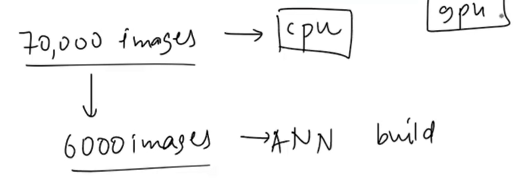

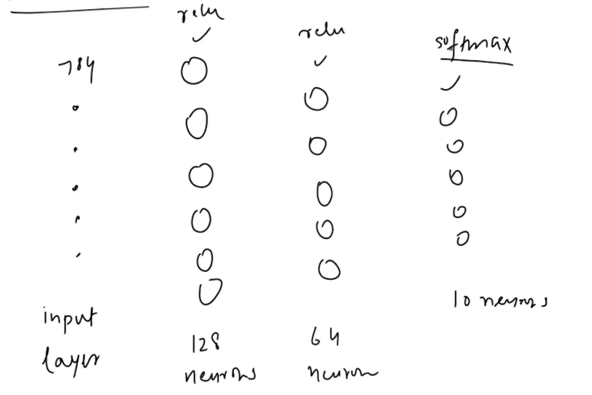

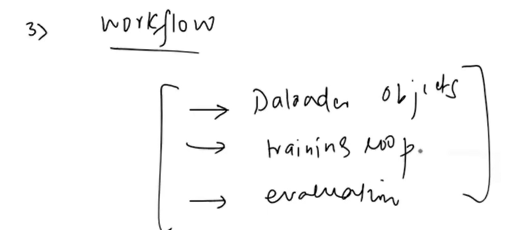

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [32]:
# Set random seeds for reproducibility
torch.manual_seed(42)


In [33]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


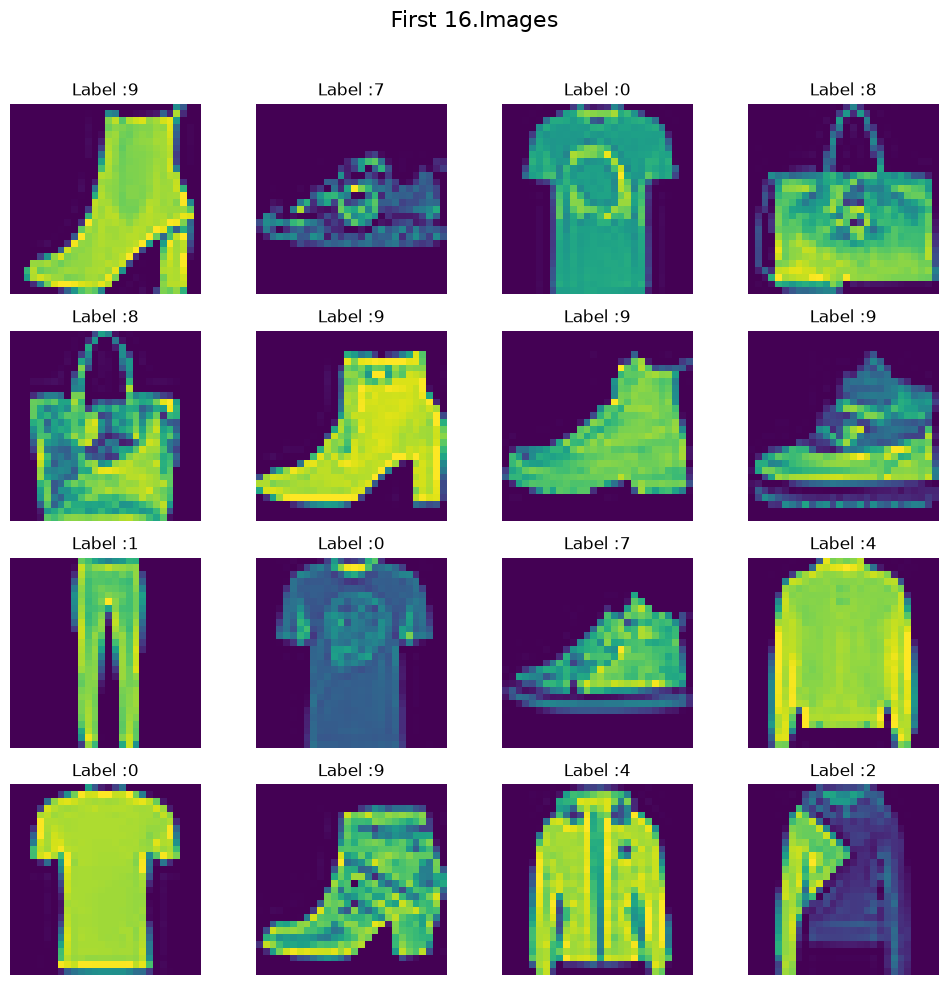

In [34]:
#Create a 4x4 grid of images
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16.Images", fontsize=16)

# Plot.the first.16.images.from the dataset
for i,ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28) # Reshape to 28x28
    ax.imshow(img)# Display in grayscale
    ax.axis('off')# Remove.axis.for .a.cleaner .look
    ax.set_title(f"Label :{df.iloc[i, 0]}") # Show.the label


plt.tight_layout(rect=[0,0,1, 0.96])# Adjust.layout to.fit.the title
plt.show()

In [35]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [36]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [39]:
# create CustomDataset Class
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features , dtype = torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
    
        return len(self.features)
        
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [40]:
# create trin _dataset object
train_dataset = CustomDataset(X_train, y_train)
len(train_dataset)

4800

In [41]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [42]:
test_dataset = CustomDataset(X_test,y_test)

In [43]:
train_loader =DataLoader(train_dataset,batch_size=32 ,shuffle=True)
test_loader =DataLoader(test_dataset,batch_size=32 ,shuffle=False)

In [60]:
#define NN Class 
class MyNN(nn.Module):
    
    def __init__(self, num_features):
    
        super().__init__()
        self.model = nn.Sequential(
        nn. Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn. ReLU(),
        nn.Linear(64,10)
        )
    def forward(self, x):
    
        return self.model(x)

In [61]:
#set learning rate

epochs =100
learning_rate =0.1


In [62]:
model = MyNN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

In [63]:
for epoch in range(epochs):
    
    total_epoch_loss = 0
    
    for batch_features, batch_labels in train_loader:
        
        # forward pass
        outputs = model(batch_features)
        
        # calculate loss
        loss = criterion(outputs, batch_labels)
        
        # back pass
        optimizer.zero_grad()
        loss.backward()
        
        # update grads
        optimizer.step()
        
        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch +1} , Loss: {avg_loss}') 


Epoch: 1 , Loss: 1.3127021090189617
Epoch: 2 , Loss: 0.7759507532914479
Epoch: 3 , Loss: 0.6455077562729518
Epoch: 4 , Loss: 0.5821081946293513
Epoch: 5 , Loss: 0.5318346200386683
Epoch: 6 , Loss: 0.5004018848141034
Epoch: 7 , Loss: 0.45852550864219666
Epoch: 8 , Loss: 0.44103615313768385
Epoch: 9 , Loss: 0.4135496750473976
Epoch: 10 , Loss: 0.38326697235306106
Epoch: 11 , Loss: 0.3831465612351894
Epoch: 12 , Loss: 0.35724768420060476
Epoch: 13 , Loss: 0.34832223077615104
Epoch: 14 , Loss: 0.33267633080482484
Epoch: 15 , Loss: 0.3169926889489094
Epoch: 16 , Loss: 0.31308656712373095
Epoch: 17 , Loss: 0.29667233914136887
Epoch: 18 , Loss: 0.28513235670824844
Epoch: 19 , Loss: 0.2692473430931568
Epoch: 20 , Loss: 0.25860818890233833
Epoch: 21 , Loss: 0.25166799455881117
Epoch: 22 , Loss: 0.2759794469177723
Epoch: 23 , Loss: 0.22955981848140558
Epoch: 24 , Loss: 0.21926882694164912
Epoch: 25 , Loss: 0.22036008502046267
Epoch: 26 , Loss: 0.22151665385812522
Epoch: 27 , Loss: 0.203150630419

In [64]:
#set model to eval mode

model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [68]:
#evaluation code
total =0
correct=0

with torch.no_grad():
    for batch_features , batch_labels in test_loader:
        
        outputs = model(batch_features)
        
        _, predicted = torch.max(outputs,1)
        
        total=total+batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()
    print(correct/total)

0.8358333333333333
